In [ ]:
from datasets import load_dataset
dataset = load_dataset("jskswamy/predictive-maintenance-data")
train_df = dataset["train"].to_pandas()


README.md:   0%|          | 0.00/1.24k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 2.92MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  391kB            

data/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  585kB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/14650 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1954 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2931 [00:00<?, ? examples/s]

In [ ]:
import pandas as pd

df_working = train_df.copy()

print("### Initial Dataset State ###")
print(f"Initial shape of the dataset: {df_working.shape}")
initial_null_count = df_working.isnull().sum().sum()
print(f"Initial total null values: {initial_null_count}")
initial_duplicate_rows = df_working.duplicated().sum()
print(f"Initial number of duplicate rows: {initial_duplicate_rows}")

print("\n### Checking for Missing Columns (all nulls) ###")
columns_with_all_nulls = df_working.columns[df_working.isnull().all()].tolist()
num_missing_columns = len(columns_with_all_nulls)

if num_missing_columns > 0:
    print(f"Found {num_missing_columns} column(s) with all null values: {columns_with_all_nulls}")
    df_working.drop(columns=columns_with_all_nulls, inplace=True)
    print("These columns have been removed.")
else:
    print("No columns found with all null values.")
print(f"Shape after checking for all-null columns: {df_working.shape}")

# --- Step 2: Remove rows with any null values ---
print("\n### Handling Null Values (row-wise) ###")
rows_before_null_drop = df_working.shape[0]
df_working.dropna(inplace=True)
rows_dropped_due_to_nulls = rows_before_null_drop - df_working.shape[0]

if rows_dropped_due_to_nulls > 0:
    print(f"Removed {rows_dropped_due_to_nulls} rows due to containing null values.")
else:
    print("No rows with null values were found to be removed.")
current_null_count = df_working.isnull().sum().sum()
print(f"Total null values after dropping rows: {current_null_count}")
print(f"Shape after dropping rows with nulls: {df_working.shape}")

print("\n### Handling Duplicate Rows ###")
rows_before_duplicate_drop = df_working.shape[0]
df_working.drop_duplicates(inplace=True)
rows_dropped_due_to_duplicates = rows_before_duplicate_drop - df_working.shape[0]

if rows_dropped_due_to_duplicates > 0:
    print(f"Removed {rows_dropped_due_to_duplicates} duplicate rows.")
else:
    print("No duplicate rows were found to be removed.")
current_duplicate_rows = df_working.duplicated().sum()
print(f"Number of duplicate rows after dropping: {current_duplicate_rows}")
print(f"Shape after dropping duplicates: {df_working.shape}")

print("\n### Final Dataset State ###")
print(f"Final shape of the cleaned dataset: {df_working.shape}")
print(f"Total null values remaining: {df_working.isnull().sum().sum()}")
print(f"Total duplicate rows remaining: {df_working.duplicated().sum()}")



### Initial Dataset State ###
Initial shape of the dataset: (14650, 23)
Initial total null values: 0
Initial number of duplicate rows: 0

### Checking for Missing Columns (all nulls) ###
No columns found with all null values.
Shape after checking for all-null columns: (14650, 23)

### Handling Null Values (row-wise) ###
No rows with null values were found to be removed.
Total null values after dropping rows: 0
Shape after dropping rows with nulls: (14650, 23)

### Handling Duplicate Rows ###
No duplicate rows were found to be removed.
Number of duplicate rows after dropping: 0
Shape after dropping duplicates: (14650, 23)

### Final Dataset State ###
Final shape of the cleaned dataset: (14650, 23)
Total null values remaining: 0
Total duplicate rows remaining: 0


In [ ]:
# Identify numerical columns
numerical_cols = df_working.select_dtypes(include=['number']).columns

print("Descriptive statistics for numerical columns before normalization:")
display(df_working[numerical_cols].describe())


Descriptive statistics for numerical columns before normalization:


,Engine RPM,Lub Oil Pressure,Fuel Pressure,Coolant Pressure,Lub Oil Temp,Coolant Temp,RPM_x_OilPressure,RPM_x_FuelPressure,RPM_x_CoolantPressure,OilTemp_x_OilPressure,...,TempDiff,OilFuelPressureRatio,CoolantOilPressureRatio,OilHealthIndex,CoolantStress,OilTempPerRPM,CoolantTempPerRPM,PressureSum,TempSum,Engine Condition
count,14650.000000,14650.000000,14650.000000,14650.000000,14650.000000,14650.000000,14650.000000,14650.000000,14650.000000,14650.000000,...,14650.000000,14650.000000,14650.000000,14650.000000,14650.000000,14650.000000,14650.000000,14650.000000,14650.000000,14650.000000
mean,791.274471,3.304687,6.657157,2.334366,77.641797,78.453505,2620.745375,5263.898517,1842.003433,256.571712,...,-0.811709,0.645999,0.956729,0.042629,46.235147,0.109238,0.110364,12.296210,156.095302,0.630512
std,266.323333,1.019266,2.762432,1.037532,3.109865,6.230348,1235.640876,2909.143545,1059.105344,79.745714,...,6.752161,2.455988,5.439537,0.013269,316.773797,0.039091,0.039920,3.184521,7.168355,0.482683
min,61.000000,0.003384,0.012640,0.002483,71.321974,62.445955,1.326572,11.160987,1.511984,0.249275,...,-119.008526,0.000628,0.000468,0.000046,9.309392,0.034439,0.033830,3.223755,136.131952,0.000000
25%,594.000000,2.523464,4.919304,1.601112,75.712314,73.884928,1748.103090,3324.339927,1125.195012,195.486769,...,-5.621704,0.369537,0.475382,0.032448,27.536837,0.082937,0.083321,10.210179,150.837853,0.000000
50%,747.000000,3.161958,6.198950,2.168231,76.812113,78.346942,2384.603889,4612.513646,1588.089535,245.189602,...,-0.744017,0.512232,0.677668,0.040834,36.084294,0.103915,0.104452,11.865188,155.864802,1.000000
75%,934.000000,4.055869,7.733656,2.843757,78.072727,82.966491,3267.814249,6449.892030,2275.349818,315.081972,...,3.874766,0.706609,0.959792,0.052259,49.069667,0.130594,0.131810,13.870721,161.001928,1.000000
max,2239.000000,7.265566,21.138326,7.478505,89.580796,195.527912,11900.091888,25551.754480,11664.764881,561.889672,...,22.669427,258.815410,444.657427,0.093948,34035.729577,1.266020,1.214561,29.913167,272.047297,1.000000


In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Initialize the MinMaxScaler
scaler = MinMaxScaler()

# Apply Min-Max scaling to the numerical columns
df_normalized = df_working.copy()
df_normalized[numerical_cols] = scaler.fit_transform(df_normalized[numerical_cols])

print("Descriptive statistics for numerical columns after Min-Max normalization:")
display(df_normalized[numerical_cols].describe())

print("\nFirst 5 rows of the DataFrame after Min-Max normalization:")
display(df_normalized.head())


Descriptive statistics for numerical columns after Min-Max normalization:


,Engine RPM,Lub Oil Pressure,Fuel Pressure,Coolant Pressure,Lub Oil Temp,Coolant Temp,RPM_x_OilPressure,RPM_x_FuelPressure,RPM_x_CoolantPressure,OilTemp_x_OilPressure,...,TempDiff,OilFuelPressureRatio,CoolantOilPressureRatio,OilHealthIndex,CoolantStress,OilTempPerRPM,CoolantTempPerRPM,PressureSum,TempSum,Engine Condition
count,14650.000000,14650.000000,14650.000000,14650.000000,14650.000000,14650.000000,14650.000000,14650.000000,14650.000000,14650.000000,...,14650.000000,14650.000000,14650.000000,14650.000000,14650.000000,14650.000000,14650.000000,14650.000000,14650.000000,14650.000000
mean,0.335296,0.454588,0.314523,0.311915,0.346124,0.120283,0.220142,0.205662,0.157803,0.456382,...,0.834264,0.002494,0.002151,0.453484,0.001085,0.060734,0.064819,0.339927,0.146881,0.630512
std,0.122279,0.140353,0.130762,0.138781,0.170321,0.046816,0.103846,0.113903,0.090807,0.141987,...,0.047659,0.009489,0.012233,0.141304,0.009310,0.031740,0.033810,0.119318,0.052741,0.482683
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.244720,0.347014,0.232261,0.213834,0.240450,0.085954,0.146803,0.129722,0.096344,0.347620,...,0.800314,0.001425,0.001068,0.345066,0.000536,0.039379,0.041915,0.261768,0.108199,0.000000
50%,0.314968,0.434935,0.292834,0.289693,0.300684,0.119483,0.200296,0.180158,0.136032,0.436116,...,0.834742,0.001977,0.001523,0.434364,0.000787,0.056412,0.059812,0.323778,0.145185,1.000000
75%,0.400826,0.558026,0.365480,0.380052,0.369726,0.154195,0.274523,0.252098,0.194957,0.560559,...,0.867342,0.002728,0.002157,0.556034,0.001169,0.078075,0.082982,0.398921,0.182981,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000



First 5 rows of the DataFrame after Min-Max normalization:


,Engine RPM,Lub Oil Pressure,Fuel Pressure,Coolant Pressure,Lub Oil Temp,Coolant Temp,RPM_x_OilPressure,RPM_x_FuelPressure,RPM_x_CoolantPressure,OilTemp_x_OilPressure,...,TempDiff,OilFuelPressureRatio,CoolantOilPressureRatio,OilHealthIndex,CoolantStress,OilTempPerRPM,CoolantTempPerRPM,PressureSum,TempSum,Engine Condition
0,0.514692,0.298492,0.182102,0.210637,0.332142,0.162209,0.215560,0.178186,0.159711,0.298703,...,0.793080,0.002171,0.001633,0.298280,0.001292,0.025197,0.031560,0.164268,0.186054,0.0
1,0.343434,0.641827,0.357579,0.359725,0.322400,0.096258,0.317025,0.239240,0.186582,0.640777,...,0.853774,0.002379,0.001297,0.642878,0.000548,0.049529,0.050133,0.438347,0.120169,0.0
2,0.458678,0.386010,0.324289,0.175568,0.729305,0.114481,0.249920,0.284414,0.119385,0.422515,...,0.889097,0.001578,0.001053,0.352652,0.001462,0.036870,0.033415,0.290805,0.192676,0.0
3,0.571625,0.623337,0.252578,0.357745,0.236676,0.077595,0.497117,0.273056,0.299628,0.609693,...,0.860257,0.003270,0.001328,0.637287,0.000525,0.019066,0.018540,0.349649,0.090379,0.0
4,0.487603,0.494821,0.238742,0.407691,0.665956,0.125450,0.339359,0.221881,0.293578,0.534190,...,0.870629,0.002746,0.001906,0.458348,0.000489,0.032397,0.031034,0.317719,0.194906,0.0


### Exploratory Data Analysis (EDA) ###

--- 1. Basic Data Information ---
Shape of the dataset (rows, columns):
(14650, 23)

Data types and non-null values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14650 entries, 0 to 14649
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Engine RPM                     14650 non-null  float64
 1   Lub Oil Pressure               14650 non-null  float64
 2   Fuel Pressure                  14650 non-null  float64
 3   Coolant Pressure               14650 non-null  float64
 4   Lub Oil Temp                   14650 non-null  float64
 5   Coolant Temp                   14650 non-null  float64
 6   RPM_x_OilPressure              14650 non-null  float64
 7   RPM_x_FuelPressure             14650 non-null  float64
 8   RPM_x_CoolantPressure          14650 non-null  float64
 9   OilTemp_x_OilPressure          14650 non-null  float64
 10  CoolantT

,Engine RPM,Lub Oil Pressure,Fuel Pressure,Coolant Pressure,Lub Oil Temp,Coolant Temp,RPM_x_OilPressure,RPM_x_FuelPressure,RPM_x_CoolantPressure,OilTemp_x_OilPressure,...,TempDiff,OilFuelPressureRatio,CoolantOilPressureRatio,OilHealthIndex,CoolantStress,OilTempPerRPM,CoolantTempPerRPM,PressureSum,TempSum,Engine Condition
count,14650.000000,14650.000000,14650.000000,14650.000000,14650.000000,14650.000000,14650.000000,14650.000000,14650.000000,14650.000000,...,14650.000000,14650.000000,14650.000000,14650.000000,14650.000000,14650.000000,14650.000000,14650.000000,14650.000000,14650.000000
mean,0.335296,0.454588,0.314523,0.311915,0.346124,0.120283,0.220142,0.205662,0.157803,0.456382,...,0.834264,0.002494,0.002151,0.453484,0.001085,0.060734,0.064819,0.339927,0.146881,0.630512
std,0.122279,0.140353,0.130762,0.138781,0.170321,0.046816,0.103846,0.113903,0.090807,0.141987,...,0.047659,0.009489,0.012233,0.141304,0.009310,0.031740,0.033810,0.119318,0.052741,0.482683
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.244720,0.347014,0.232261,0.213834,0.240450,0.085954,0.146803,0.129722,0.096344,0.347620,...,0.800314,0.001425,0.001068,0.345066,0.000536,0.039379,0.041915,0.261768,0.108199,0.000000
50%,0.314968,0.434935,0.292834,0.289693,0.300684,0.119483,0.200296,0.180158,0.136032,0.436116,...,0.834742,0.001977,0.001523,0.434364,0.000787,0.056412,0.059812,0.323778,0.145185,1.000000
75%,0.400826,0.558026,0.365480,0.380052,0.369726,0.154195,0.274523,0.252098,0.194957,0.560559,...,0.867342,0.002728,0.002157,0.556034,0.001169,0.078075,0.082982,0.398921,0.182981,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000



--- 3. Missing Values Check ---
No missing values found in the dataset.

--- 4. Target Variable Analysis: 'Engine Condition' ---
Distribution of 'Engine Condition':


,count
Engine Condition,
1.0,9237
0.0,5413


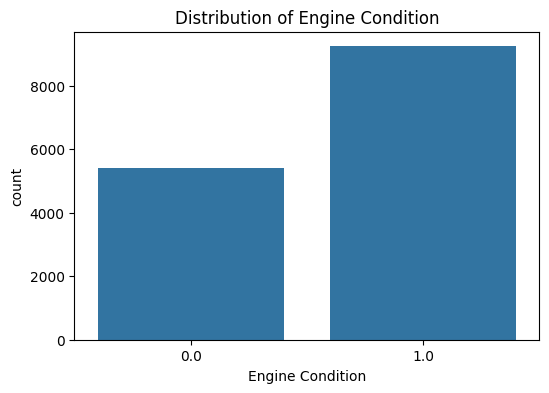


--- 5. Distribution of Key Numerical Features (Histograms) ---


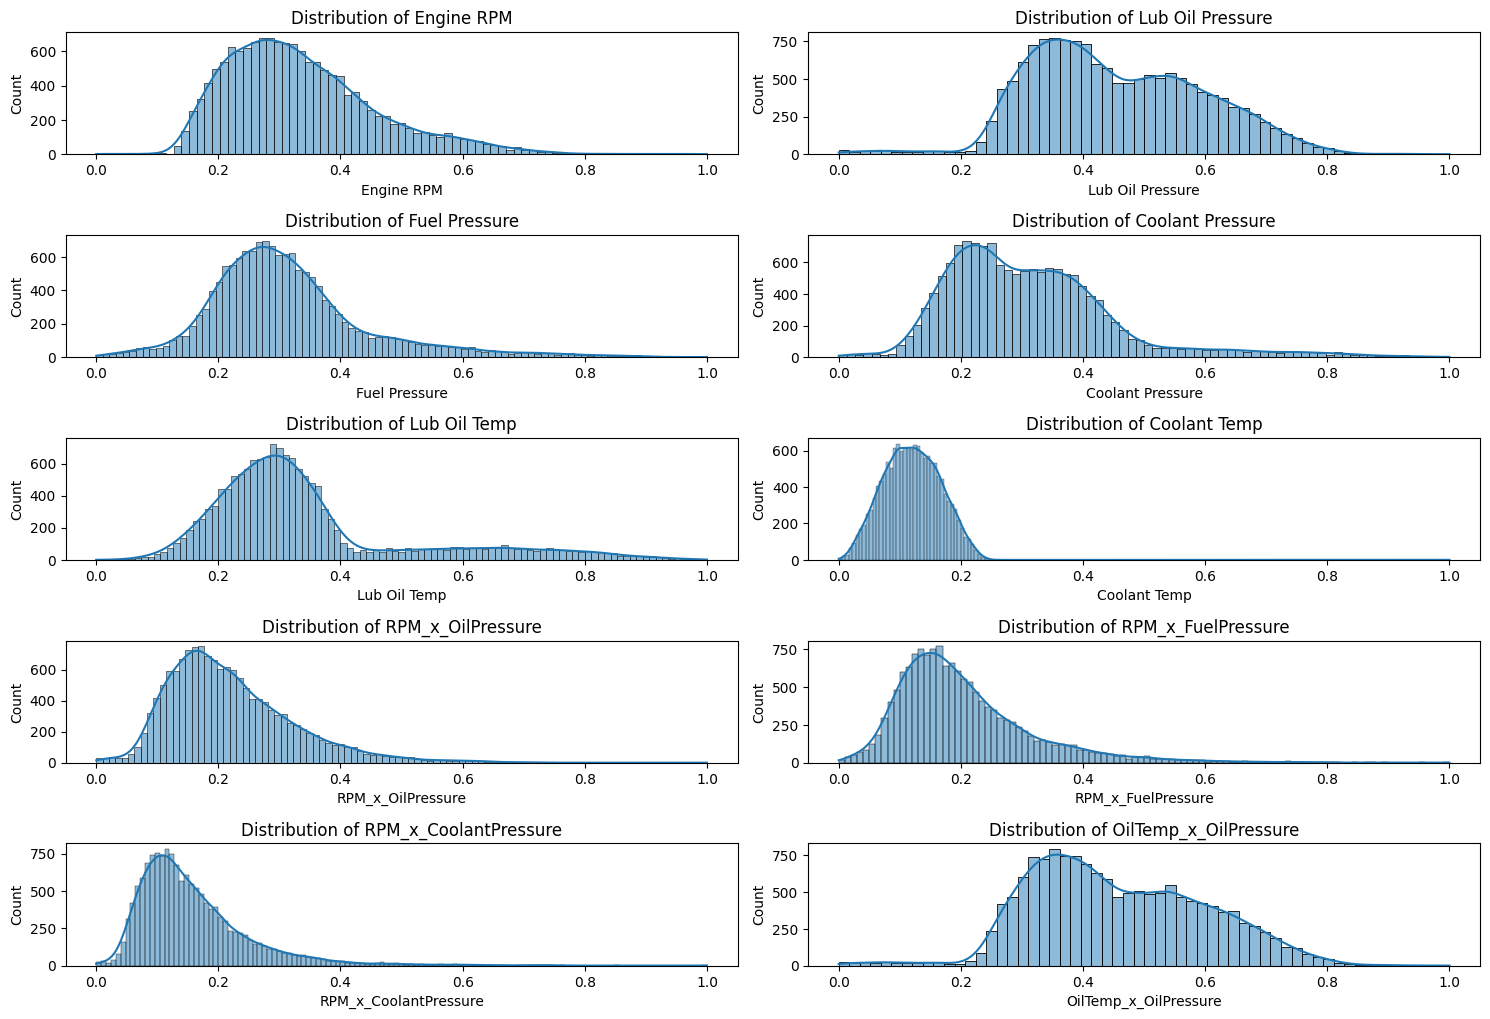


--- 6. Correlation Matrix Heatmap ---


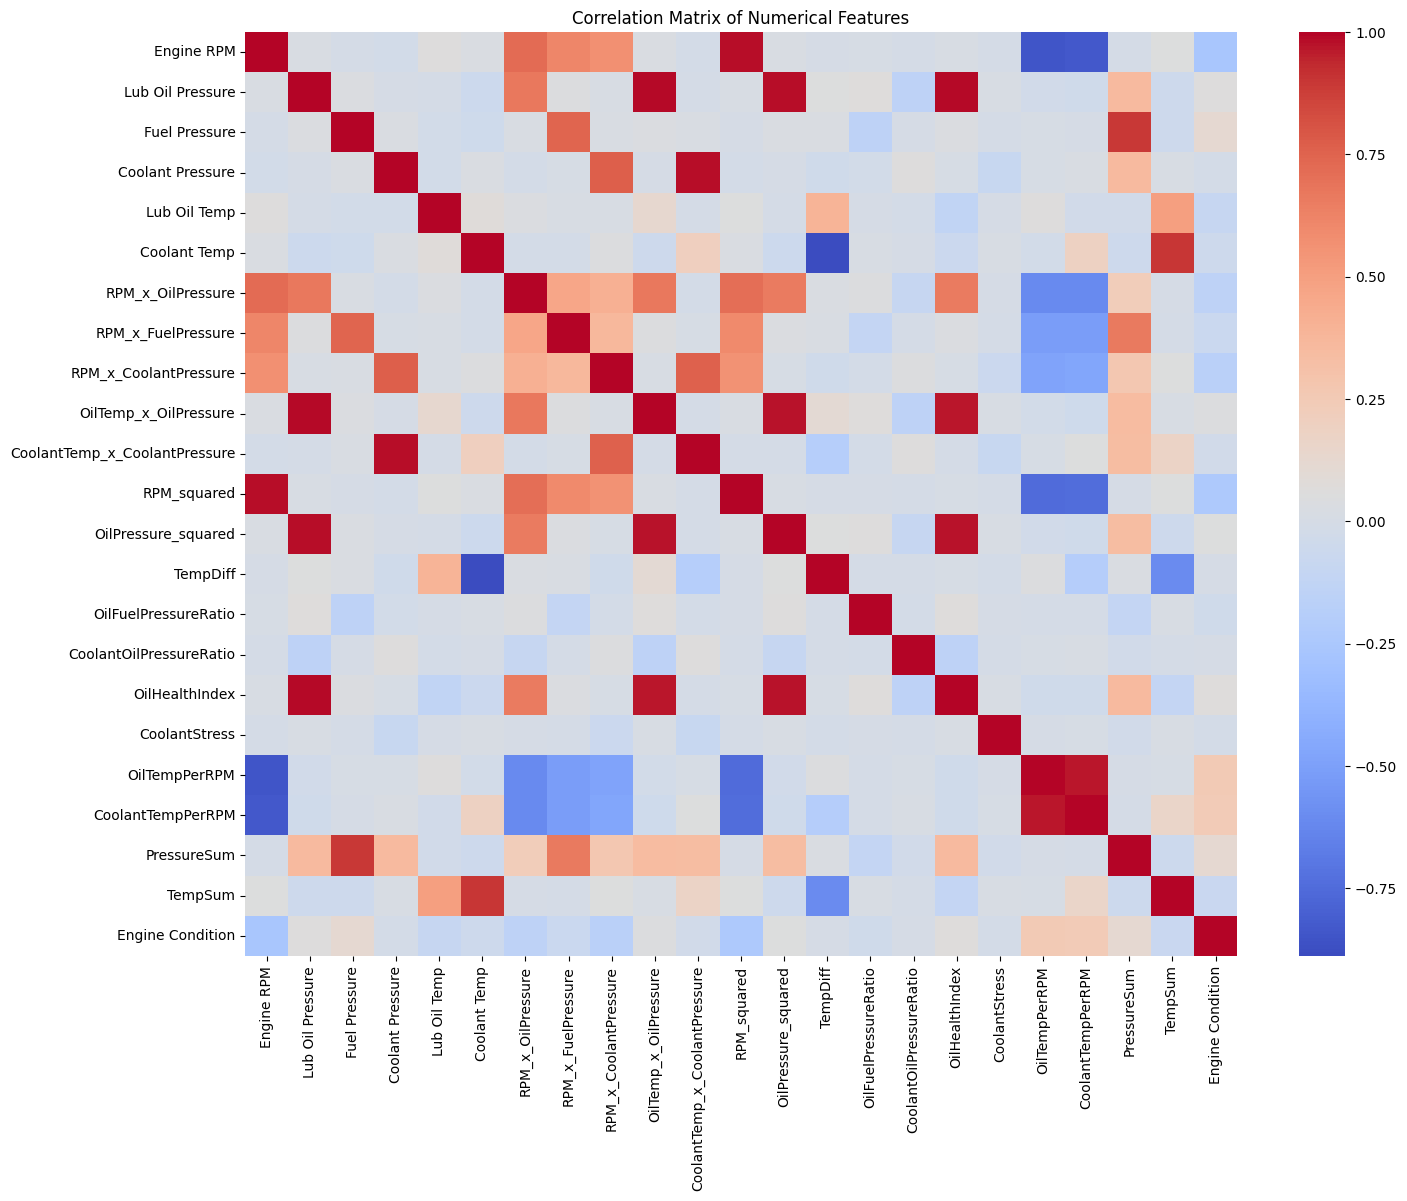


EDA complete. You can further explore specific features using scatter plots, pair plots, or box plots for outlier detection if needed.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("### Exploratory Data Analysis (EDA) ###")

# 1. Basic Data Information
print("\n--- 1. Basic Data Information ---")
print("Shape of the dataset (rows, columns):")
print(df_normalized.shape)
print("\nData types and non-null values:")
df_normalized.info()

# 2. Descriptive Statistics for Numerical Features
print("\n--- 2. Descriptive Statistics (Normalized Numerical Features) ---")
display(df_normalized.describe())

# 3. Missing Values Check (already confirmed clean in previous step, but good to re-check)
print("\n--- 3. Missing Values Check ---")
missing_values = df_normalized.isnull().sum()
missing_values = missing_values[missing_values > 0]
if missing_values.empty:
    print("No missing values found in the dataset.")
else:
    print("Missing values by column:")
    print(missing_values)

# 4. Target Variable Analysis: 'Engine Condition'
print("\n--- 4. Target Variable Analysis: 'Engine Condition' ---")
print("Distribution of 'Engine Condition':")
display(df_normalized['Engine Condition'].value_counts())
plt.figure(figsize=(6, 4))
sns.countplot(x='Engine Condition', data=df_normalized)
plt.title('Distribution of Engine Condition')
plt.show()

# 5. Distribution of Numerical Features
print("\n--- 5. Distribution of Key Numerical Features (Histograms) ---")
# Select a few key numerical columns for visualization, excluding the target variable
# Ensure 'Engine Condition' is treated as the target, not a feature for these plots
features_to_plot = [col for col in numerical_cols if col != 'Engine Condition']

# Plot histograms for a sample of numerical features
# To avoid plotting too many, we'll select the first 10 numerical features if available
num_plots = min(10, len(features_to_plot))

if num_plots > 0:
    plt.figure(figsize=(15, num_plots * 2))
    for i, col in enumerate(features_to_plot[:num_plots]):
        plt.subplot(num_plots, 2, i + 1)
        sns.histplot(df_normalized[col], kde=True)
        plt.title(f'Distribution of {col}')
    plt.tight_layout()
    plt.show()
else:
    print("No numerical features to plot after excluding 'Engine Condition'.")

# 6. Correlation Matrix (for numerical features)
print("\n--- 6. Correlation Matrix Heatmap ---")
plt.figure(figsize=(16, 12))
correlation_matrix = df_normalized[numerical_cols].corr()



































sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

print("\nEDA complete. You can further explore specific features using scatter plots, pair plots, or box plots for outlier detection if needed.")
